In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from loguru import logger
from src.constants import EYE_BY_WORD_DF_L1_PATH, EYE_DF_L2_PATH
from typing import List, Union, Literal
import scipy.stats
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:

def lin_model_multi(data, eye_measure, readability_metrics):
    # Fit and summarize OLS model
    readability_diff_dict = {}
    eye_measure_diff = np.array(data[eye_measure + '_diff'])


    for r_metric in readability_metrics:
        readability_diff_dict[r_metric] = data[r_metric+"_diff"]

    X = pd.DataFrame.from_dict(readability_diff_dict)
    X = sm.add_constant(X)

    lin_model = sm.OLS(eye_measure_diff, X).fit()

    print(lin_model.summary())

In [3]:
def plot_scatter(data: pd.DataFrame, eye_measure: str, readability_measure: str, eye_measure_name: str):
    
    sns.regplot(x=readability_measure+"_diff", y=eye_measure+"_diff", data=data, x_bins=20)
    plt.title(f"{eye_measure_name} as function of {readability_measure}")
    plt.ylabel(eye_measure_name)
    plt.xlabel(readability_measure)
    plt.figure(constrained_layout=True)
    plt.show()

    g = sns.jointplot(x=readability_measure+"_diff", y=eye_measure+"_diff", data=data, kind='reg')
    # We're going to make the regression line red so it's easier to see
    regline = g.ax_joint.get_lines()[0]
    _ = regline.set_color('red')
    plt.show()

In [4]:
level = "sentence"
filtered = "_filtered"
not_filtered = ""

filtered = not_filtered

In [5]:
src_path = Path.cwd().parents[0]
path_to_df = src_path / Path(f"all_metrics/results/all_metrics_L1_gathering_1st_{level}{filtered}.csv")  

all_measures = pd.read_csv(path_to_df)
eye_measure = "RegRateTotal"
metrics =  [
    'flesch_reading_ease',
    'flesch_kincaid_grade_score', 
    'gunning_fog_index', 
    'coleman_liau_index',
    'smog_index', 
    'dale_chall_score',
    'linsear_formula', 
    'ARI',
    'surprisal', 
    'CARES',
    'CAREC',
    'CAREC_M',
    'CML2RI']
lin_model_multi(all_measures, "TF", metrics)

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.227
Model:                            OLS   Adj. R-squared:                  0.214
Method:                 Least Squares   F-statistic:                     17.56
Date:                Wed, 30 Oct 2024   Prob (F-statistic):           6.55e-36
Time:                        04:50:06   Log-Likelihood:                -4039.4
No. Observations:                 793   AIC:                             8107.
Df Residuals:                     779   BIC:                             8172.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const               

In [6]:
src_path = Path.cwd().parents[0]
path_to_df = src_path / Path(f"all_metrics/results/all_metrics_L1_gathering_1st_{level}{filtered}.csv")  

all_measures = pd.read_csv(path_to_df)
eye_measure = "RegRateTotal"
metrics =  [
    'flesch_reading_ease',
    'flesch_kincaid_grade_score', 
    'gunning_fog_index', 
    'coleman_liau_index',
    'smog_index', 
    'dale_chall_score',
    'linsear_formula', 
    'ARI',
    'surprisal', 
    'CARES',
    'CAREC',
    'CAREC_M',
    'CML2RI']
for metric in metrics:
    lin_model_multi(all_measures, "TF", [metric])

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.050
Model:                            OLS   Adj. R-squared:                  0.049
Method:                 Least Squares   F-statistic:                     41.50
Date:                Wed, 30 Oct 2024   Prob (F-statistic):           2.05e-10
Time:                        04:50:06   Log-Likelihood:                -4121.0
No. Observations:                 793   AIC:                             8246.
Df Residuals:                     791   BIC:                             8255.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   2.6968    

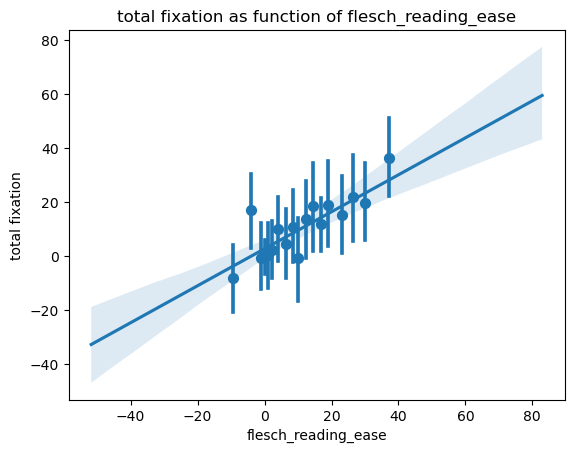

<Figure size 640x480 with 0 Axes>

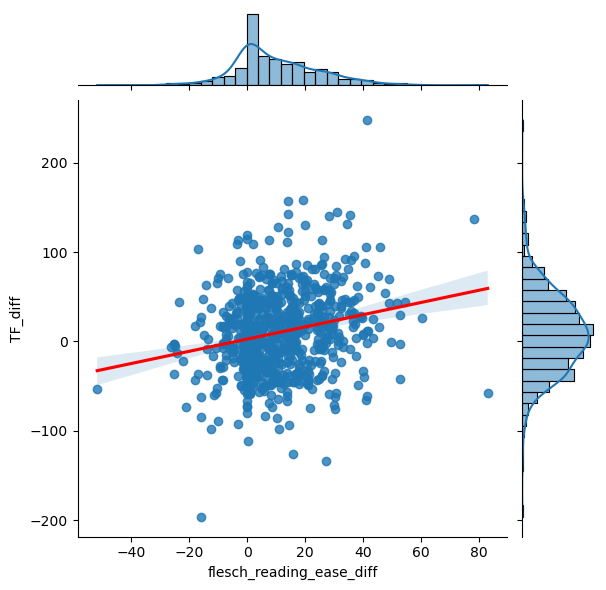

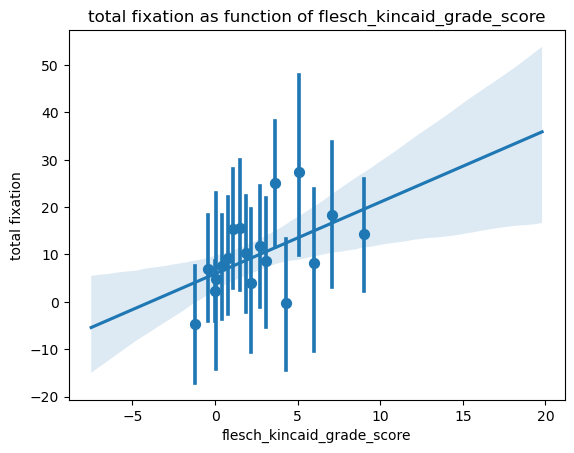

<Figure size 640x480 with 0 Axes>

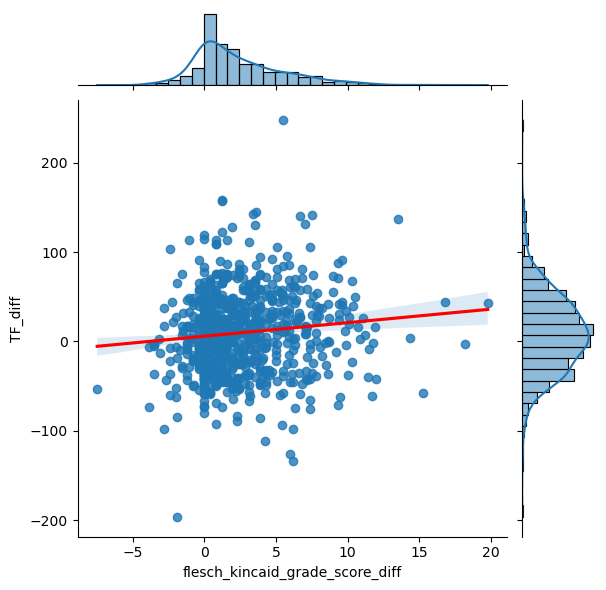

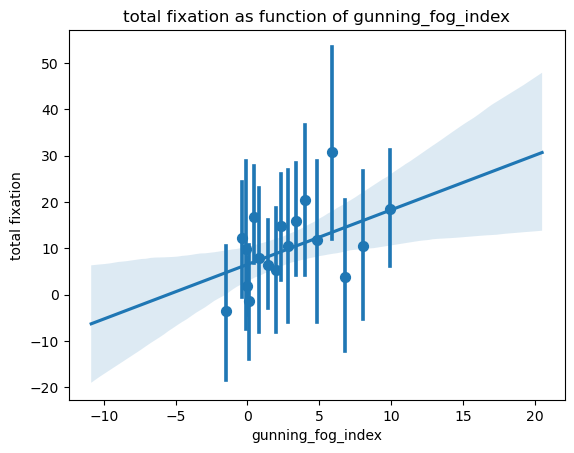

<Figure size 640x480 with 0 Axes>

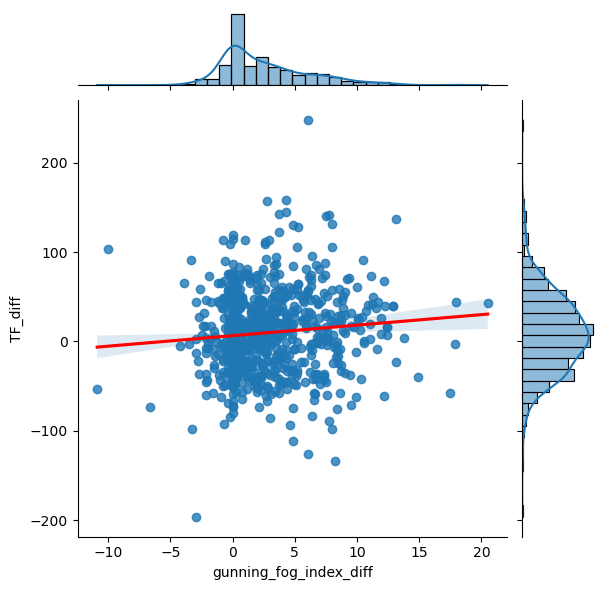

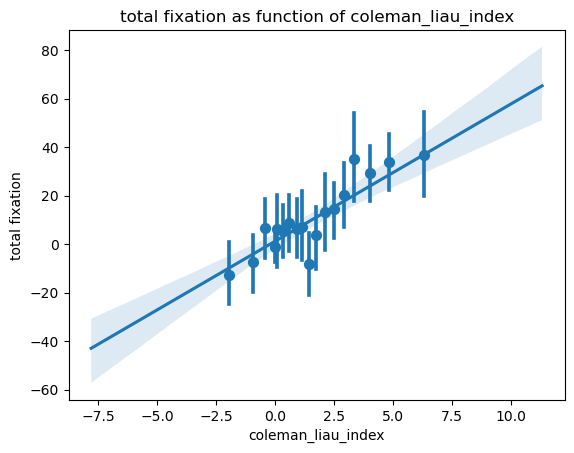

<Figure size 640x480 with 0 Axes>

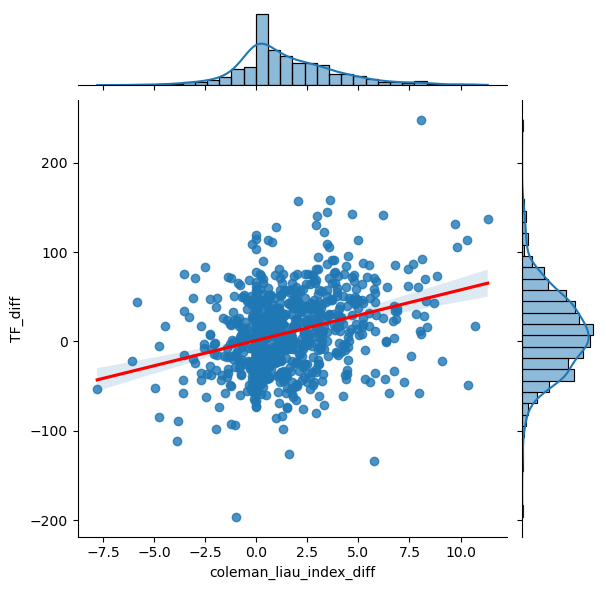

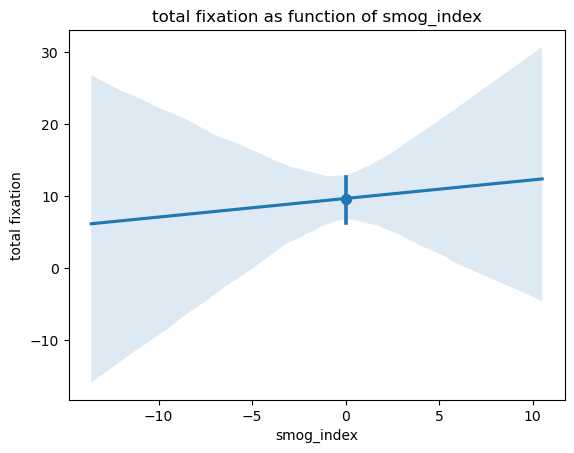

<Figure size 640x480 with 0 Axes>

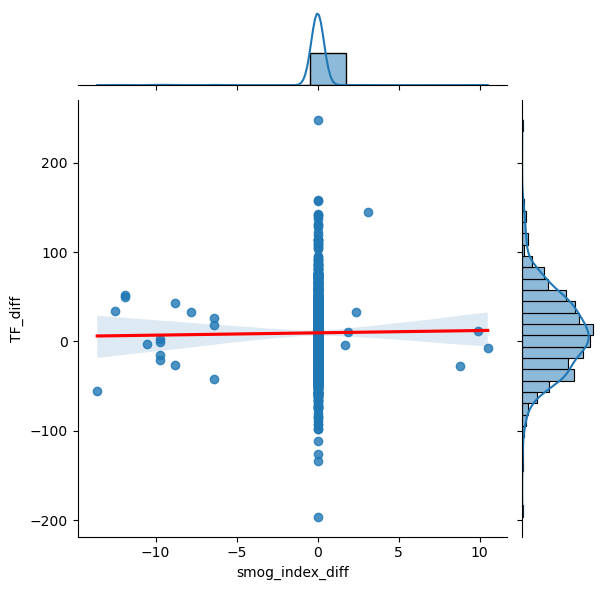

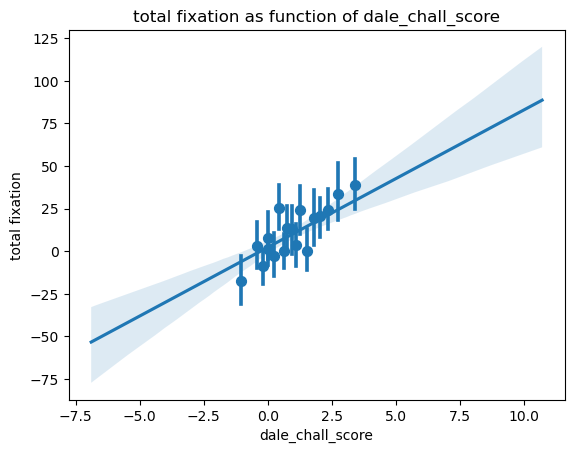

<Figure size 640x480 with 0 Axes>

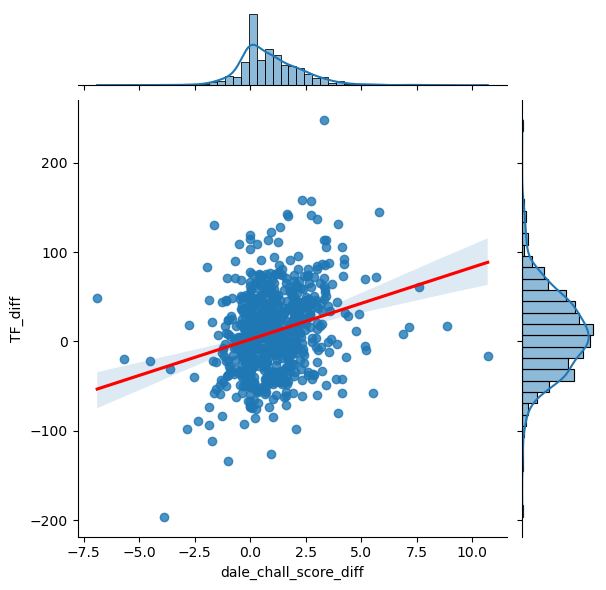

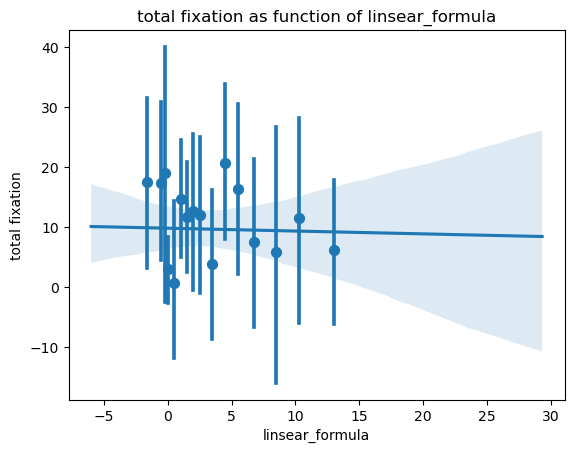

<Figure size 640x480 with 0 Axes>

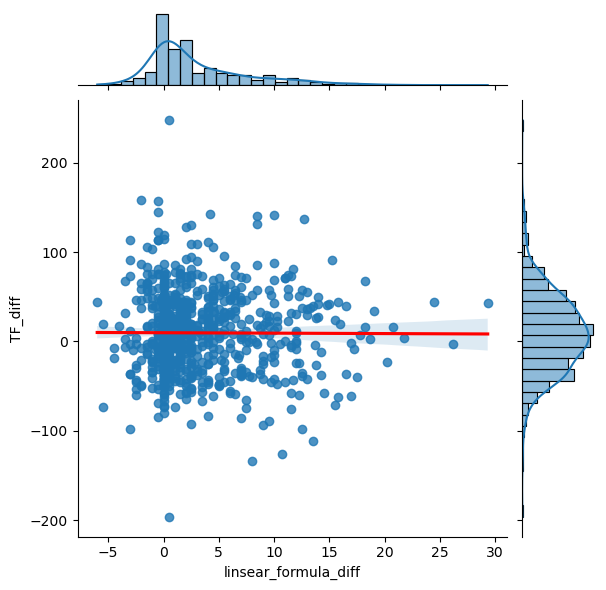

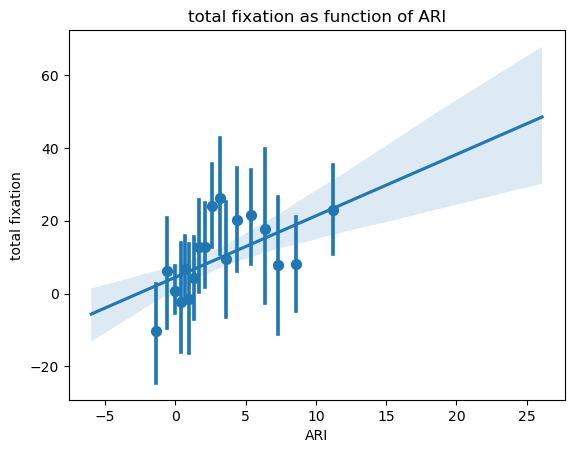

<Figure size 640x480 with 0 Axes>

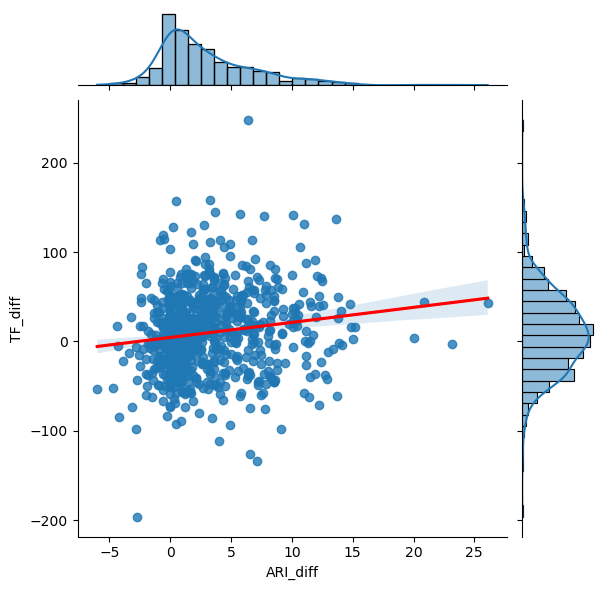

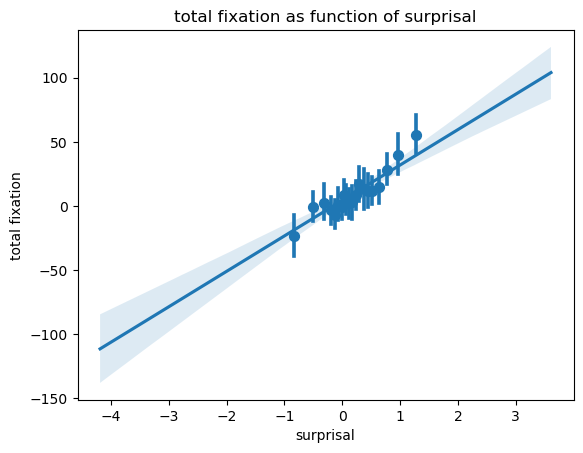

<Figure size 640x480 with 0 Axes>

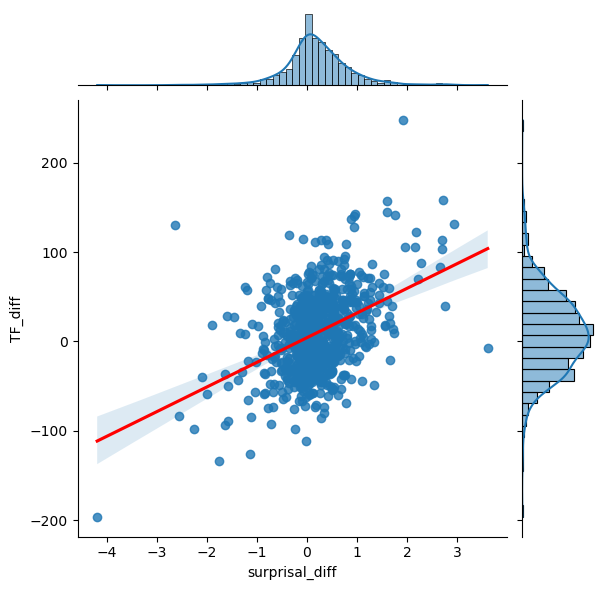

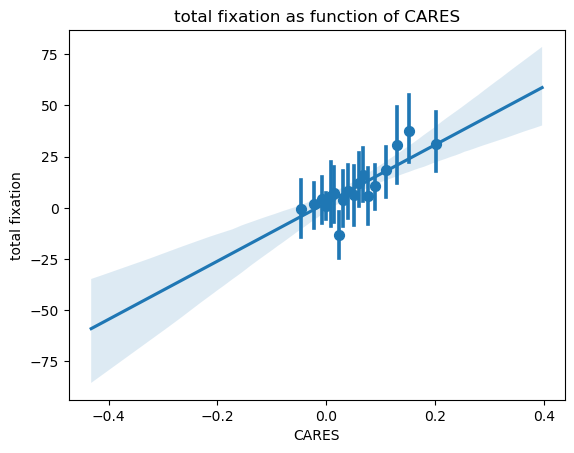

<Figure size 640x480 with 0 Axes>

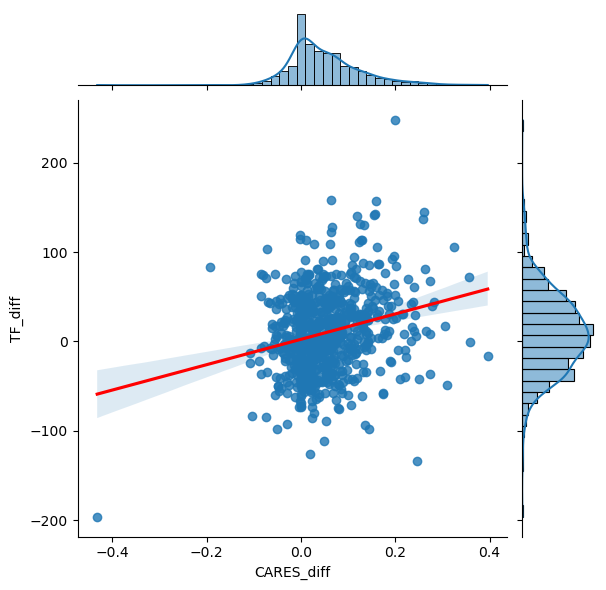

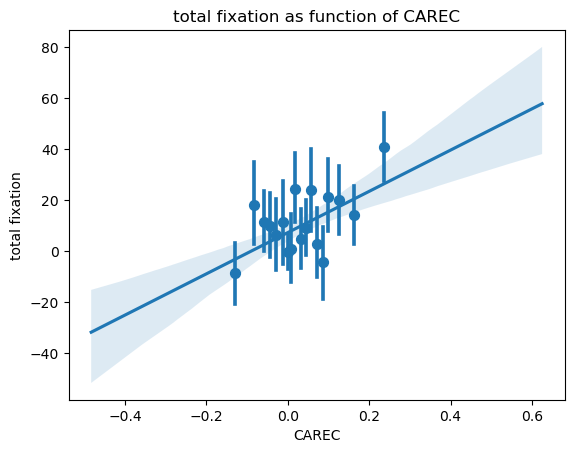

<Figure size 640x480 with 0 Axes>

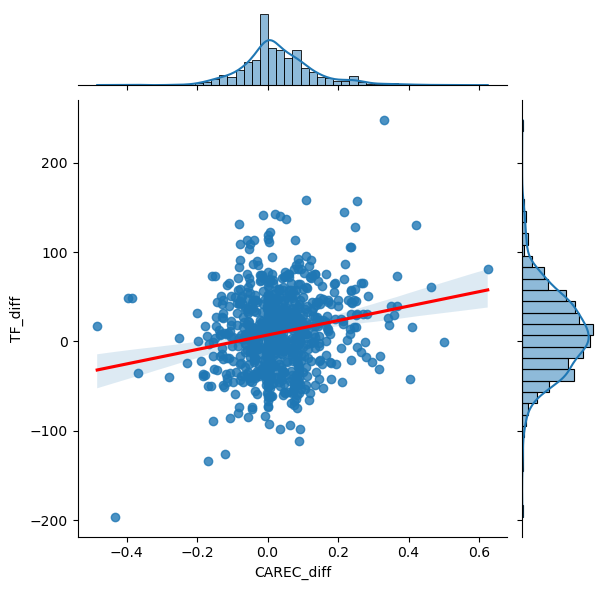

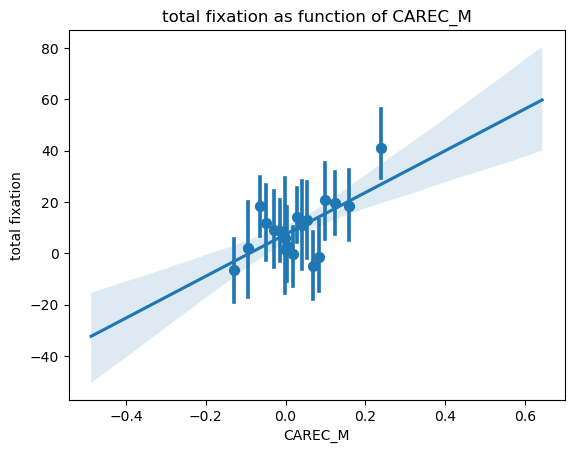

<Figure size 640x480 with 0 Axes>

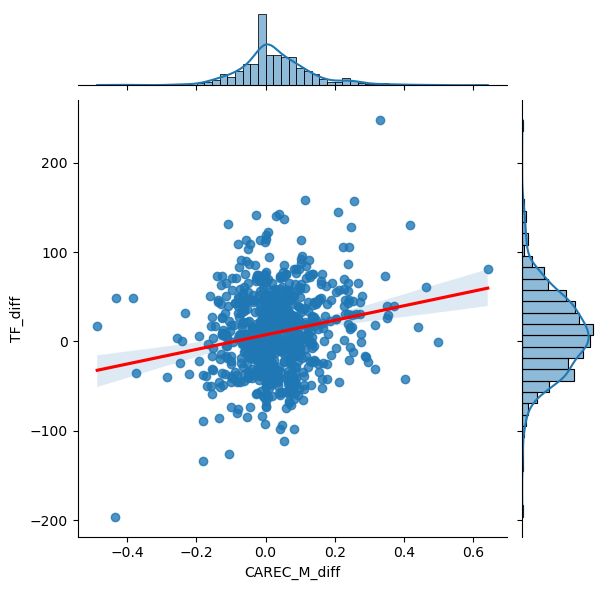

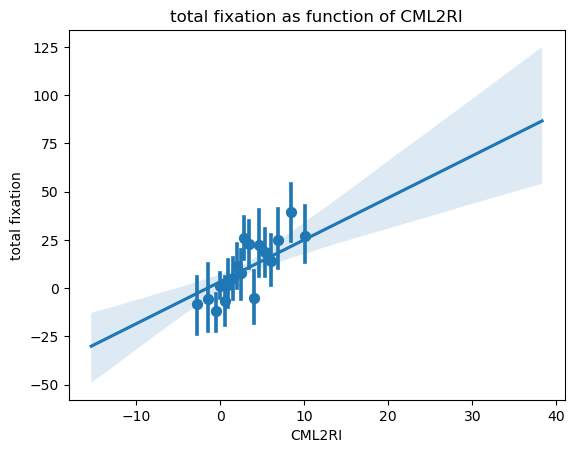

<Figure size 640x480 with 0 Axes>

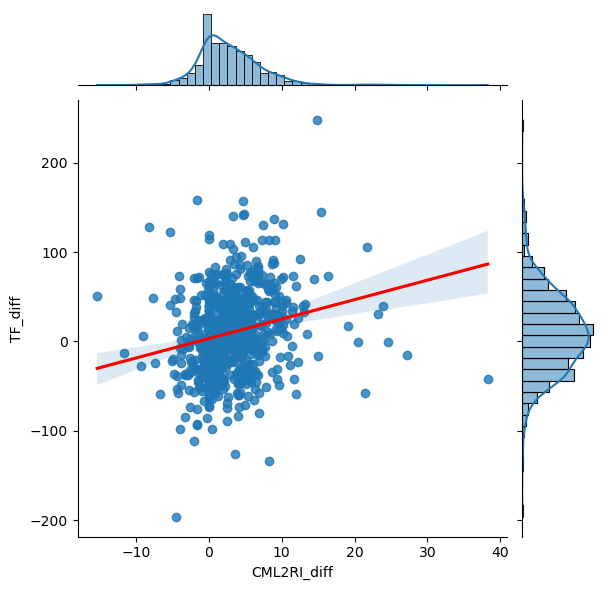

In [7]:
src_path = Path.cwd().parents[0]
path_to_df = src_path / Path(f"all_metrics/results/all_metrics_L1_gathering_1st_{level}{filtered}.csv")  

all_measures = pd.read_csv(path_to_df)
eye_measure = "RegRateTotal"
metrics = [
    'flesch_reading_ease',
    'flesch_kincaid_grade_score', 
    'gunning_fog_index', 
    'coleman_liau_index',
    'smog_index', 
    'dale_chall_score',
    'linsear_formula', 
    'ARI',
    'surprisal', 
    'CARES',
    'CAREC',
    'CAREC_M',
    'CML2RI']

for r_metric in metrics:
    plot_scatter(all_measures, "TF", r_metric, "total fixation")